# 外窗策略跨形态适用性
本笔记本读取已完成的144次EnergyPlus模拟，并可重新执行分组回归。热量不是电耗。

In [1]:
from pathlib import Path
import csv,json,sys,subprocess
ROOT=Path.cwd()
assert (ROOT/"results/summary.json").exists(), "请从项目根目录打开笔记本"
S=json.loads((ROOT/"results/summary.json").read_text())
print("Completed simulations:",S["n_cases"])
print("Glass better than specified shade:",S["glass_beats_shade_contexts"],"/",S["n_contexts"])

Completed simulations: 144
Glass better than specified shade: 36 / 36


## 数据与EDA
读取全部结果，并显示同条件下四个方案比较。

{'case_id': 'r1_o000_w20_baseline', 'aspect_ratio': '1', 'length_m': '30.0', 'width_m': '30.0', 'orientation_deg': '0', 'wwr': '0.2', 'strategy': 'baseline', 'shgc': '0.6', 'overhang_m': '0.0', 'floor_area_m2': '900', 'pilot': '0', 'cooling_kwh_th': '107341.04426119318', 'cooling_kwh_th_m2': '119.26782695688131', 'peak_hourly_cooling_kw_th': '61.47175352377664', 'hours': '8760', 'warnings': '6', 'runtime_seconds': '2.366792499786243', 'input_hash': '076f8156a080557b57981935134d2a38cdb488a52c507d70dcf10b0b595b6c4a'}


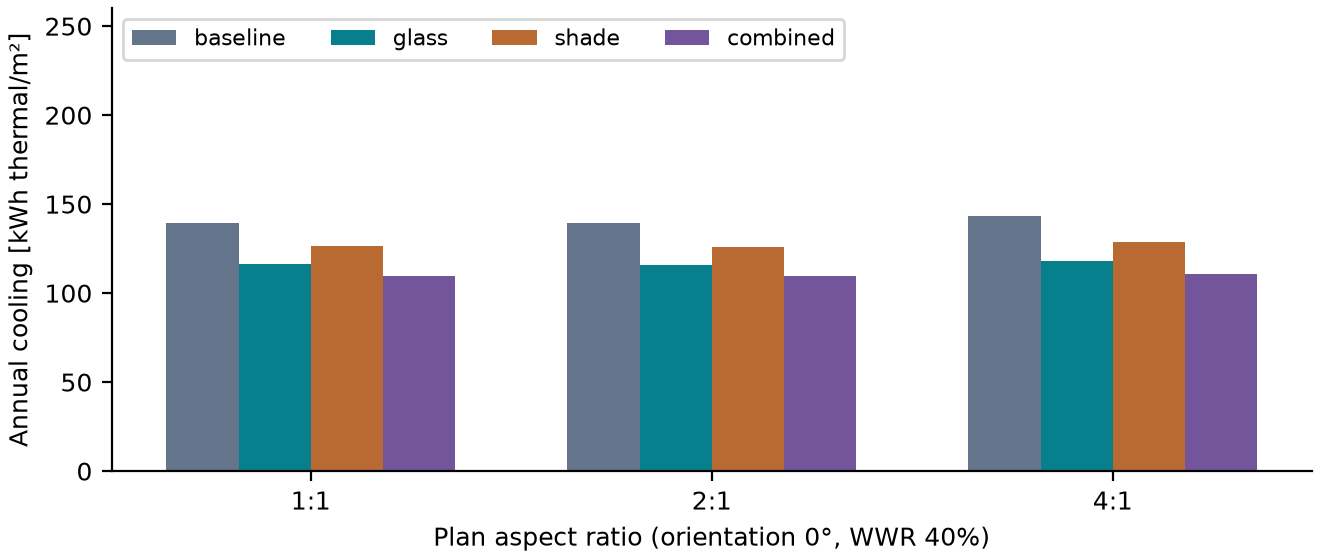

In [2]:
with (ROOT/"results/full_results.csv").open(encoding="utf-8-sig") as f:
    rows=list(csv.DictReader(f))
print(rows[0])
from IPython.display import Image,display
display(Image(filename=str(ROOT/"results/figures/cooling_comparison.png")))

## 重新计算留出预测
相同情景不拆分，整种形态留出为主要迁移检验；超参数固定。

In [3]:
subprocess.run([sys.executable,str(ROOT/"scripts/study.py"),"analyze"],check=True)
subprocess.run([sys.executable,str(ROOT/"scripts/summarize.py")],check=True,capture_output=True)
with (ROOT/"results/pooled_metrics.csv").open(encoding="utf-8-sig") as f:
    for row in csv.DictReader(f):
        print(row["scheme"],row["model"],"MAE",round(float(row["mae"]),3))

within_shape_context_holdout mean MAE 15.264
within_shape_context_holdout strategy_mean MAE 11.775
within_shape_context_holdout ridge MAE 2.841
within_shape_context_holdout forest MAE 2.77
leave_one_shape_out mean MAE 14.107
leave_one_shape_out strategy_mean MAE 10.252
leave_one_shape_out ridge MAE 2.866
leave_one_shape_out forest MAE 2.947


## 解释边界
所有方案选择损失为零也不能证明AI有效：玻璃在所有情景中都优于所选挑檐，固定选择玻璃也能达到相同结果。外部形态、不同面积及运行敏感性仍待完成。